In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FraudDetection") \
    .getOrCreate()

spark


26/01/02 16:05:43 WARN Utils: Your hostname, DESKTOP-DD5N9SQ resolves to a loopback address: 127.0.1.1; using 172.17.138.117 instead (on interface eth0)
26/01/02 16:05:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


:: loading settings :: url = jar:file:/home/souhail/.local/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/souhail/.ivy2/cache
The jars for the packages stored in: /home/souhail/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-027fcb69-9b8b-4073-a1cf-827e8cae9bd4;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.4.1 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.4.1 in central
	found org.apache.kafka#kafka-clients;3.3.2 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.1 in central
	found org.slf4j#slf4j-api;2.0.6 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.4 in central
	found org.apache.hadoop#hadoop-client-api;3.3.4 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central
:: resolution report :: resolve 2113ms :: artifacts dl 73ms


In [2]:
df = spark.read.csv("../dataset/creditcard.csv", header=True, inferSchema=True)

In [3]:
df.show(5)


26/01/02 16:06:33 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|                V9|                V10|               V11|               V12|               V13|               V14|               V15|               V16|               V17|                V18|               V19|                V20|                 V21|                V22|     

In [4]:
# Convertir en Pandas (attention si le dataset est très grand !)
import pandas as pd

data_pd = df.limit(5).toPandas()
display(data_pd)  # si tu es dans Jupyter Notebook

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
class_counts = df.groupBy("Class").count().toPandas()
class_counts


,Class,count
0,1,492
1,0,284315


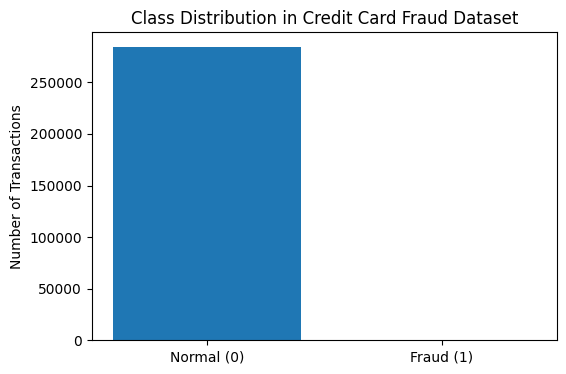

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(class_counts["Class"], class_counts["count"])
plt.xticks([0, 1], ["Normal (0)", "Fraud (1)"])
plt.ylabel("Number of Transactions")
plt.title("Class Distribution in Credit Card Fraud Dataset")
plt.show()


In [7]:
from pyspark.sql.functions import when, col

# Séparer les classes
df_class_0 = df.filter(col("Class") == 0)
df_class_1 = df.filter(col("Class") == 1)

# 1. Sous-échantillonnage léger de la classe 0 (par exemple 50% des normaux)
df_class_0_sampled = df_class_0.sample(withReplacement=False, fraction=0.4, seed=42)

# 2. Sur-échantillonnage de la classe 1 (par exemple multiplier par 10 pour augmenter les fraudes)
df_class_1_oversampled = df_class_1.sample(withReplacement=True, fraction=15.0, seed=42)

# 3. Combiner les deux classes pour créer un dataset plus équilibré
df_combined = df_class_0_sampled.union(df_class_1_oversampled)

   Class   count
0      0  113661
1      1    7491


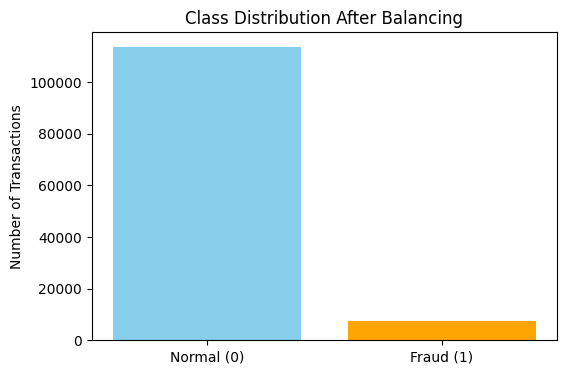

In [8]:
# 1. Count new class distribution
class_counts_balanced = df_combined.groupBy("Class").count().toPandas()
print(class_counts_balanced)

# 2. Plot the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(class_counts_balanced["Class"], class_counts_balanced["count"], color=["skyblue", "orange"])
plt.xticks([0, 1], ["Normal (0)", "Fraud (1)"])
plt.ylabel("Number of Transactions")
plt.title("Class Distribution After Balancing")
plt.show()


In [11]:
train_df, test_df = df_combined.randomSplit([0.8, 0.2], seed=42)

In [12]:
print("Train count:", train_df.count())
print("Test count :", test_df.count())

train_df.groupBy("Class").count().show()
test_df.groupBy("Class").count().show()


Train count: 97162


Test count : 23990


+-----+-----+
|Class|count|
+-----+-----+
|    0|91148|
|    1| 6014|
+-----+-----+



+-----+-----+
|Class|count|
+-----+-----+
|    0|22513|
|    1| 1477|
+-----+-----+



In [14]:
test_df.coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("../test_transactions")


In [15]:
test_df.printSchema()


root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: double (nullable = true)
 |-- V28: double (nulla

In [16]:
test_df_no_class = test_df.drop("Class")


In [17]:
test_df_no_class.coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("../test_transactions_no_class")
